# MobiFall v2 - Classical ML Pipeline

This notebook downloads **MobiFall Dataset v2.0** directly from **Kaggle**, loads the accelerometer and gyroscope trials in the same style as the deep learning notebook, converts each signal window into handcrafted features, and trains the following classical machine learning models:

- Logistic Regression
- Naive Bayes
- SVM
- Decision Tree
- Random Forest
- XGBoost

The notebook supports three tasks:

- **binary**: fall vs ADL
- **fall4**: classify only the 4 fall types
- **multi13**: classify all 13 activities


## 1. Install dependencies

In [ ]:
!pip install -q kagglehub xgboost scipy

## 2. Download the dataset from Kaggle

In [ ]:
import os
import kagglehub

path = kagglehub.dataset_download("kmknation/mobifall-dataset-v20")
print("Downloaded to:", path)

ROOT = "/root/.cache/kagglehub/datasets/kmknation/mobifall-dataset-v20/versions/1/MobiFall_Dataset_v2.0"
print("Exists:", os.path.exists(ROOT))
if os.path.exists(ROOT):
    print("Top contents:", os.listdir(ROOT)[:10])

100%|██████████| 90.2M/90.2M [00:00<00:00, 101MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/kmknation/mobifall-dataset-v20/versions/1
Exists: True
Top contents: ['sub19', 'sub9', 'sub15', 'sub30', 'sub8', 'sub1', 'sub18', 'sub20', 'sub11', 'sub4']


## 3. Inspect dataset structure

In [ ]:
def tree(path, prefix="", max_depth=3, depth=0):
    if depth >= max_depth:
        return
    try:
        entries = sorted(os.listdir(path))
    except Exception:
        return
    for i, name in enumerate(entries[:15]):
        full = os.path.join(path, name)
        connector = "└── " if i == len(entries[:15]) - 1 else "├── "
        print(prefix + connector + name)
        if os.path.isdir(full):
            extension = "    " if i == len(entries[:15]) - 1 else "│   "
            tree(full, prefix + extension, max_depth=max_depth, depth=depth + 1)

if os.path.exists(ROOT):
    tree(ROOT, max_depth=3)

├── Readme.txt
├── sub1
│   └── FALLS
│       ├── BSC
│       ├── FKL
│       ├── FOL
│       └── SDL
├── sub10
│   ├── ADL
│   │   ├── CSI
│   │   ├── CSO
│   │   ├── JOG
│   │   ├── JUM
│   │   ├── SCH
│   │   ├── STD
│   │   ├── STN
│   │   ├── STU
│   │   └── WAL
│   └── FALLS
│       ├── BSC
│       ├── FKL
│       ├── FOL
│       └── SDL
├── sub11
│   ├── ADL
│   │   ├── CSI
│   │   ├── CSO
│   │   ├── JOG
│   │   ├── JUM
│   │   ├── SCH
│   │   ├── STD
│   │   ├── STN
│   │   ├── STU
│   │   └── WAL
│   └── FALLS
│       ├── BSC
│       ├── FKL
│       ├── FOL
│       └── SDL
├── sub12
│   └── FALLS
│       ├── BSC
│       ├── FKL
│       ├── FOL
│       └── SDL
├── sub13
│   └── FALLS
│       ├── BSC
│       ├── FKL
│       ├── FOL
│       └── SDL
├── sub14
│   └── FALLS
│       ├── BSC
│       ├── FKL
│       ├── FOL
│       └── SDL
├── sub15
│   └── FALLS
│       ├── BSC
│       ├── FKL
│       ├── FOL
│       └── SDL
├── sub16
│   └── FALLS
│       ├── BSC
│       ├── FKL
│ 

## 4. Helper functions for loading MobiFall files

In [ ]:
import glob
import re
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
from tqdm import tqdm

def load_mobifall_file(path):
    with open(path, "r", errors="ignore") as f:
        lines = f.readlines()

    start = next(i for i, l in enumerate(lines) if l.strip() == "@DATA") + 1

    rows = []
    for line in lines[start:]:
        line = line.strip().rstrip(",")
        if not line:
            continue
        parts = [p.strip() for p in line.split(",")]
        if len(parts) != 4:
            continue
        try:
            rows.append([int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])])
        except ValueError:
            continue

    return pd.DataFrame(rows, columns=["t_ns", "x", "y", "z"])


def enumerate_trials(root):
    files = glob.glob(f"{root}/**/*.txt", recursive=True)
    by_key = defaultdict(lambda: {"sensors": set(), "paths": {}})
    pat = re.compile(r"([A-Z]{3})_(acc|gyro|ori)_(\d+)_(\d+)\.txt$")

    for f in files:
        base = os.path.basename(f)
        m = pat.match(base)
        if not m:
            continue

        act, sensor, subj_id, trial = m.groups()
        parts = f.split(os.sep)
        category = parts[-3]
        subject = parts[-4]

        key = (subject, category, act, int(trial))
        by_key[key]["sensors"].add(sensor)
        by_key[key]["paths"][sensor] = f

    trials = []
    paths_map = {}
    for k, info in by_key.items():
        if {"acc", "gyro"}.issubset(info["sensors"]):
            trials.append(k)
            paths_map[k] = info["paths"]

    trials.sort(key=lambda t: (int(t[0][3:]), t[1], t[2], t[3]))
    return trials, paths_map


def load_trial(paths, target_hz=100):
    acc = load_mobifall_file(paths["acc"])
    gyro = load_mobifall_file(paths["gyro"])

    t0 = max(acc["t_ns"].iloc[0], gyro["t_ns"].iloc[0])
    t1 = min(acc["t_ns"].iloc[-1], gyro["t_ns"].iloc[-1])

    step_ns = int(1e9 / target_hz)
    grid = np.arange(t0, t1, step_ns)

    def interp_xyz(df, grid):
        return np.stack([
            np.interp(grid, df["t_ns"], df["x"]),
            np.interp(grid, df["t_ns"], df["y"]),
            np.interp(grid, df["t_ns"], df["z"]),
        ], axis=1)

    X = np.concatenate([interp_xyz(acc, grid), interp_xyz(gyro, grid)], axis=1)
    return X.astype(np.float32), grid

## 5. Enumerate valid trials and inspect coverage

In [ ]:
trials, paths_map = enumerate_trials(ROOT)
print("Total valid acc+gyro trials:", len(trials))

activity_counts = Counter([act for (_, _, act, _) in trials])
category_counts = Counter([cat for (_, cat, _, _) in trials])
subject_counts = Counter([subj for (subj, _, _, _) in trials])

print("Activities:", dict(sorted(activity_counts.items())))
print("Categories:", dict(category_counts))
print("Number of subjects:", len(subject_counts))
print("Example trial:", trials[0] if trials else None)

Total valid acc+gyro trials: 630
Activities: {'BSC': 72, 'CSI': 54, 'CSO': 54, 'FKL': 72, 'FOL': 72, 'JOG': 27, 'JUM': 27, 'SCH': 54, 'SDL': 72, 'STD': 9, 'STN': 54, 'STU': 54, 'WAL': 9}
Categories: {'FALLS': 288, 'ADL': 342}
Number of subjects: 24
Example trial: ('sub1', 'FALLS', 'BSC', 1)


## 6. Load all trials into memory

Each trial becomes a synchronized array of shape **(T, 6)** where the channels are:

`[acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z]`

In [ ]:
all_trials = []
failed = []

for key in tqdm(trials):
    subj, cat, act, trial_no = key
    try:
        X, t = load_trial(paths_map[key], target_hz=100)
        all_trials.append({
            "subject": int(subj[3:]),
            "category": cat,
            "activity": act,
            "trial": trial_no,
            "X": X,
            "n_samples": X.shape[0]
        })
    except Exception as e:
        failed.append((key, str(e)))

print("Loaded trials:", len(all_trials))
print("Failed trials:", len(failed))
if all_trials:
    print("Example shape:", all_trials[0]["X"].shape)
    print("Example metadata:", {k: all_trials[0][k] for k in ["subject", "category", "activity", "trial"]})

100%|██████████| 630/630 [00:22<00:00, 27.78it/s]

Loaded trials: 630
Failed trials: 0
Example shape: (981, 6)
Example metadata: {'subject': 1, 'category': 'FALLS', 'activity': 'BSC', 'trial': 1}


## 7. Convert time-series windows into classical ML features

For deep learning, the notebook kept each window as a full sequence.
For classical ML, each window is summarized into handcrafted statistical features.

In [ ]:
from scipy.stats import skew, kurtosis, iqr

FALL_ACTIVITIES = ["FOL", "FKL", "BSC", "SDL"]
ADL_ACTIVITIES  = ["STD", "WAL", "JOG", "JUM", "STU", "STN", "SCH", "CSI", "CSO"]
ALL_ACTIVITIES  = FALL_ACTIVITIES + ADL_ACTIVITIES

act_to_idx_13 = {a: i for i, a in enumerate(ALL_ACTIVITIES)}
act_to_idx_4  = {a: i for i, a in enumerate(FALL_ACTIVITIES)}

CHANNEL_NAMES = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]

def window_trial(X, win_size, stride, max_windows=30):
    T = X.shape[0]
    if T < win_size:
        return np.empty((0, win_size, X.shape[1]), dtype=X.dtype)

    starts = list(range(0, T - win_size + 1, stride))
    if len(starts) > max_windows:
        idx = np.linspace(0, len(starts) - 1, max_windows).astype(int)
        starts = [starts[i] for i in idx]

    return np.stack([X[s:s + win_size] for s in starts], axis=0)


def zero_crossing_rate(x):
    return np.mean(np.diff(np.signbit(x)).astype(np.float32))


def signal_features_1d(x):
    x = np.asarray(x, dtype=np.float32)
    eps = 1e-8
    return [
        np.mean(x),
        np.std(x),
        np.min(x),
        np.max(x),
        np.median(x),
        np.percentile(x, 25),
        np.percentile(x, 75),
        iqr(x),
        np.sqrt(np.mean(x ** 2)),
        np.mean(np.abs(x)),
        np.sum(x ** 2) / len(x),
        skew(x, bias=False) if np.std(x) > eps else 0.0,
        kurtosis(x, bias=False) if np.std(x) > eps else 0.0,
        zero_crossing_rate(x),
    ]


def extract_window_features(window):
    feats = []
    feat_names = []
    stat_names = [
        "mean", "std", "min", "max", "median", "p25", "p75", "iqr",
        "rms", "mav", "energy", "skew", "kurtosis", "zcr"
    ]

    for ch_idx, ch_name in enumerate(CHANNEL_NAMES):
        vals = signal_features_1d(window[:, ch_idx])
        feats.extend(vals)
        feat_names.extend([f"{ch_name}_{n}" for n in stat_names])

    acc_mag = np.linalg.norm(window[:, 0:3], axis=1)
    gyro_mag = np.linalg.norm(window[:, 3:6], axis=1)

    for mag_name, mag_vals in [("acc_mag", acc_mag), ("gyro_mag", gyro_mag)]:
        vals = signal_features_1d(mag_vals)
        feats.extend(vals)
        feat_names.extend([f"{mag_name}_{n}" for n in stat_names])

    return np.array(feats, dtype=np.float32), feat_names


def build_ml_dataset(all_trials, win_seconds=2, fs=100, overlap=0.5, max_windows=30):
    win_size = int(win_seconds * fs)
    stride = int(win_size * (1 - overlap))
    if stride < 1:
        stride = 1

    X_feat = []
    y_activity = []
    y_category = []
    y_subject = []
    y_trial = []
    feature_names = None

    for tr in tqdm(all_trials):
        windows = window_trial(tr["X"], win_size, stride, max_windows=max_windows)
        if len(windows) == 0:
            continue

        for w in windows:
            feats, names = extract_window_features(w)
            X_feat.append(feats)
            y_activity.append(tr["activity"])
            y_category.append(tr["category"])
            y_subject.append(tr["subject"])
            y_trial.append((tr["subject"], tr["activity"], tr["trial"]))
            if feature_names is None:
                feature_names = names

    X_feat = np.vstack(X_feat).astype(np.float32)
    y_activity = np.array(y_activity)
    y_category = np.array(y_category)
    y_subject = np.array(y_subject)

    y_binary = (y_category == "FALLS").astype(np.int64)
    fall_mask = np.array([a in FALL_ACTIVITIES for a in y_activity])
    y_fall4 = np.array([act_to_idx_4[a] if a in FALL_ACTIVITIES else -1 for a in y_activity], dtype=np.int64)
    y_multi13 = np.array([act_to_idx_13[a] for a in y_activity], dtype=np.int64)

    return {
        "X": X_feat,
        "feature_names": feature_names,
        "y_activity": y_activity,
        "y_category": y_category,
        "y_subject": y_subject,
        "y_trial": y_trial,
        "y_binary": y_binary,
        "y_fall4": y_fall4,
        "y_multi13": y_multi13,
        "fall_mask": fall_mask,
    }

## 8. Build the feature dataset

In [ ]:
WINDOW_SECONDS = 2
FS = 100
OVERLAP = 0.5
MAX_WINDOWS_PER_TRIAL = 30

ml_ds = build_ml_dataset(
    all_trials,
    win_seconds=WINDOW_SECONDS,
    fs=FS,
    overlap=OVERLAP,
    max_windows=MAX_WINDOWS_PER_TRIAL
)

print("Feature matrix shape:", ml_ds["X"].shape)
print("Number of features:", len(ml_ds["feature_names"]))
print("Binary class counts:", np.bincount(ml_ds["y_binary"]))
print("First 10 feature names:", ml_ds["feature_names"][:10])

100%|██████████| 630/630 [01:40<00:00,  6.26it/s]

Feature matrix shape: (5877, 112)
Number of features: 112
Binary class counts: [3565 2312]
First 10 feature names: ['acc_x_mean', 'acc_x_std', 'acc_x_min', 'acc_x_max', 'acc_x_median', 'acc_x_p25', 'acc_x_p75', 'acc_x_iqr', 'acc_x_rms', 'acc_x_mav']


## 9. Choose task

Set `TASK` to one of:

- `"binary"`
- `"fall4"`
- `"multi13"`

In [ ]:
def get_task_data(ds, task="binary"):
    if task == "binary":
        X = ds["X"]
        y = ds["y_binary"]
        groups = ds["y_subject"]
    elif task == "fall4":
        mask = ds["fall_mask"]
        X = ds["X"][mask]
        y = ds["y_fall4"][mask]
        groups = ds["y_subject"][mask]
    elif task == "multi13":
        X = ds["X"]
        y = ds["y_multi13"]
        groups = ds["y_subject"]
    else:
        raise ValueError("task must be one of: binary, fall4, multi13")
    return X, y, groups

TASK = "binary"
X, y, groups = get_task_data(ml_ds, task=TASK)

print("Task:", TASK)
print("X shape:", X.shape)
print("Class counts:", np.bincount(y))
print("Subjects:", np.unique(groups))

Task: binary
X shape: (5877, 112)
Class counts: [3565 2312]
Subjects: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 29 30 31]


## 10. Create subject-wise train/test split

We split by **subject** so windows from the same person do not appear in both train and test sets.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

def make_grouped_train_test_split(X, y, groups, test_size=0.2, random_state=42):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))
    return train_idx, test_idx

train_idx, test_idx = make_grouped_train_test_split(X, y, groups, test_size=0.2, random_state=42)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train class counts:", np.bincount(y_train))
print("Test class counts :", np.bincount(y_test))
print("Train subjects:", np.unique(groups[train_idx]))
print("Test subjects :", np.unique(groups[test_idx]))

Train shape: (5001, 112)
Test shape : (876, 112)
Train class counts: [3169 1832]
Test class counts : [396 480]
Train subjects: [ 2  3  4  5  6  7  8 10 11 13 14 15 16 18 20 21 29 30 31]
Test subjects : [ 1  9 12 17 19]


## 11. Define and train ML models

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

n_classes = len(np.unique(y_train))
avg_type = "binary" if n_classes == 2 else "macro"

models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]),

    "Naive Bayes": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", GaussianNB())
    ]),

    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced"))
    ]),

    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", DecisionTreeClassifier(max_depth=12, min_samples_leaf=3, class_weight="balanced", random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),
}

if n_classes == 2:
    models["XGBoost"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])
else:
    models["XGBoost"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            num_class=n_classes,
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1
        ))
    ])

results = []
cms = {}
fitted_models = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average=avg_type, zero_division=0)
    prec = precision_score(y_test, y_pred, average=avg_type, zero_division=0)
    rec = recall_score(y_test, y_pred, average=avg_type, zero_division=0)

    results.append({
        "model": model_name,
        "accuracy": acc,
        "f1": f1,
        "precision": prec,
        "recall": rec
    })

    cms[model_name] = confusion_matrix(y_test, y_pred)
    fitted_models[model_name] = model

    print(f"{model_name}: Acc={acc:.4f}, F1={f1:.4f}, Precision={prec:.4f}, Recall={rec:.4f}")

results_df = pd.DataFrame(results).sort_values(["f1", "accuracy"], ascending=False).reset_index(drop=True)
results_df


Training Logistic Regression...
Logistic Regression: Acc=0.9007, F1=0.9133, Precision=0.8757, Recall=0.9542

Training Naive Bayes...
Naive Bayes: Acc=0.8196, F1=0.8364, Precision=0.8313, Recall=0.8417

Training SVM...
SVM: Acc=0.9452, F1=0.9513, Precision=0.9269, Recall=0.9771

Training Decision Tree...
Decision Tree: Acc=0.8607, F1=0.8806, Precision=0.8303, Recall=0.9375

Training Random Forest...
Random Forest: Acc=0.9292, F1=0.9381, Precision=0.9004, Recall=0.9792

Training XGBoost...
XGBoost: Acc=0.9509, F1=0.9562, Precision=0.9361, Recall=0.9771


,model,accuracy,f1,precision,recall
0,XGBoost,0.950913,0.956167,0.936128,0.977083
1,SVM,0.945205,0.951318,0.926877,0.977083
2,Random Forest,0.929224,0.938124,0.900383,0.979167
3,Logistic Regression,0.900685,0.913260,0.875717,0.954167
4,Decision Tree,0.860731,0.880626,0.830258,0.937500
5,Naive Bayes,0.819635,0.836439,0.831276,0.841667


## 12. View confusion matrices

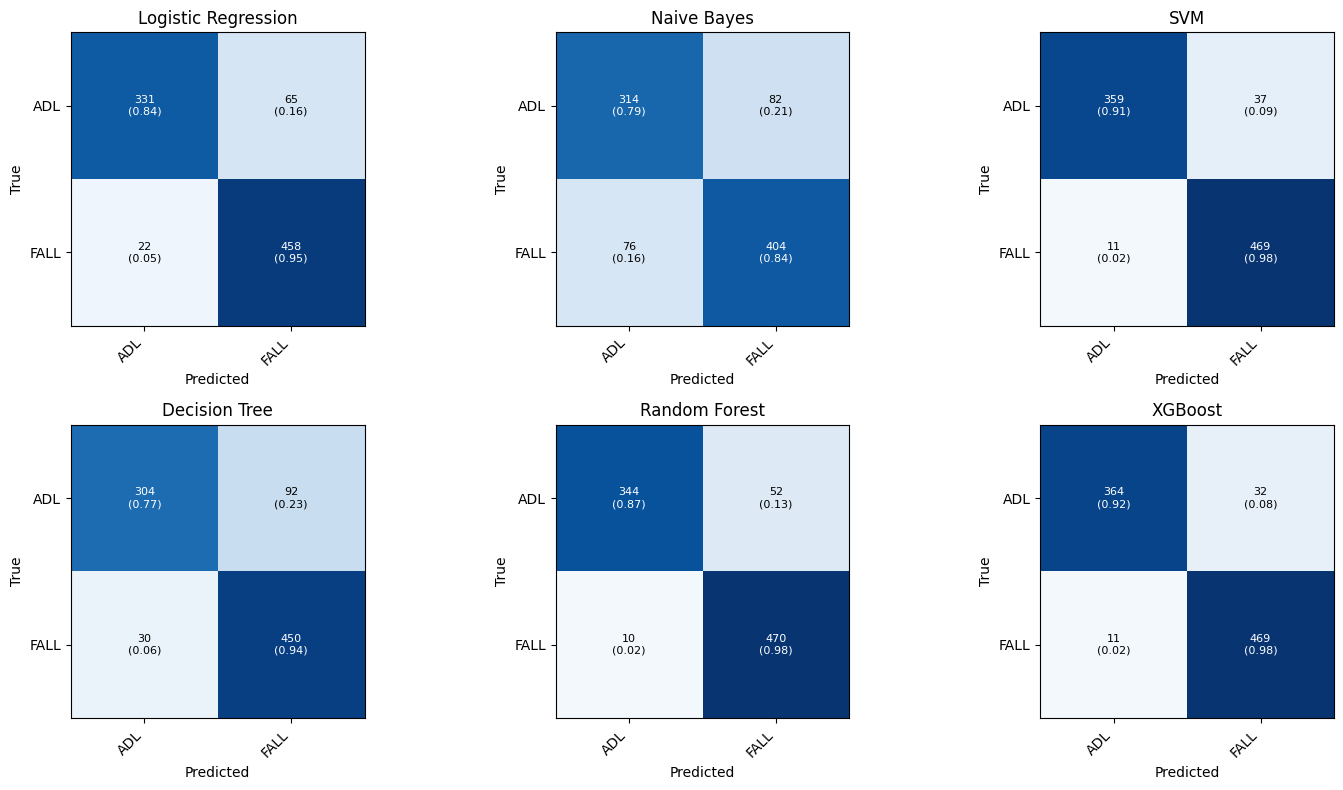

In [ ]:
import matplotlib.pyplot as plt
import math

if TASK == "binary":
    class_names = ["ADL", "FALL"]
elif TASK == "fall4":
    class_names = ["FOL", "FKL", "BSC", "SDL"]
else:
    class_names = ALL_ACTIVITIES

n_models = len(cms)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (model_name, cm) in zip(axes, cms.items()):
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f"{cm[i, j]}\n({cm_norm[i, j]:.2f})",
                ha="center", va="center",
                color="white" if cm_norm[i, j] > 0.5 else "black",
                fontsize=8
            )

    ax.set_title(model_name)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

for k in range(len(cms), len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()

## 13. Optional: inspect feature importance

This works best for tree-based models such as **Random Forest** and **XGBoost**.

Best model: XGBoost


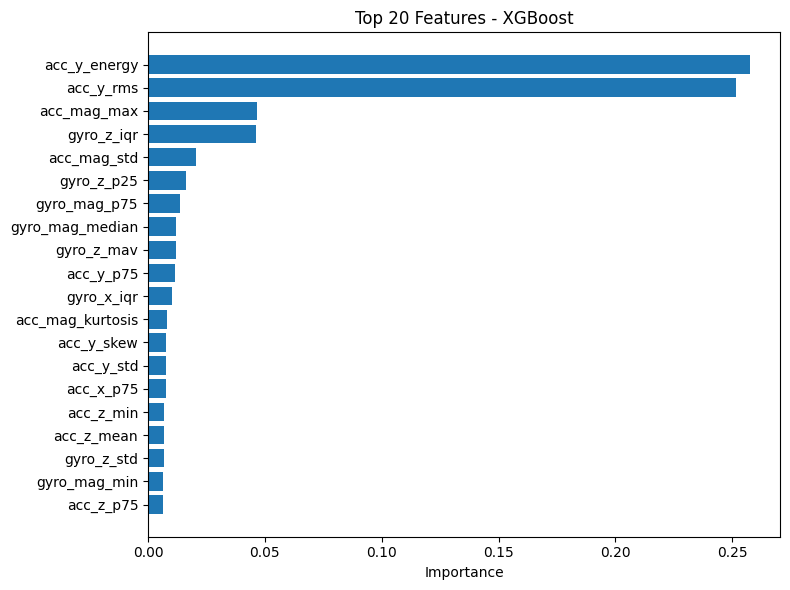

In [ ]:
TOP_MODEL_NAME = results_df.iloc[0]["model"]
print("Best model:", TOP_MODEL_NAME)

best_model = fitted_models[TOP_MODEL_NAME]
clf = best_model.named_steps["clf"] if hasattr(best_model, "named_steps") else best_model

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
    feat_df = pd.DataFrame({
        "feature": ml_ds["feature_names"],
        "importance": importances
    }).sort_values("importance", ascending=False).head(20)

    plt.figure(figsize=(8, 6))
    plt.barh(feat_df["feature"][::-1], feat_df["importance"][::-1])
    plt.xlabel("Importance")
    plt.title(f"Top 20 Features - {TOP_MODEL_NAME}")
    plt.tight_layout()
    plt.show()

    feat_df
else:
    print(f"Feature importance is not directly available for {TOP_MODEL_NAME}.")

## 14. Save results

In [ ]:
OUT = "/content/mobifall_ml_outputs"
os.makedirs(OUT, exist_ok=True)

results_path = os.path.join(OUT, f"mobifall_{TASK}_ml_results.csv")
results_df.to_csv(results_path, index=False)

features_path = os.path.join(OUT, f"mobifall_{TASK}_feature_names.txt")
with open(features_path, "w") as f:
    for name in ml_ds["feature_names"]:
        f.write(name + "\n")

print("Saved results to:", results_path)
print("Saved feature names to:", features_path)

Saved results to: /content/mobifall_ml_outputs/mobifall_binary_ml_results.csv
Saved feature names to: /content/mobifall_ml_outputs/mobifall_binary_feature_names.txt


## Notes

- This notebook keeps the **same data access pattern** as your DL notebook: Kaggle download -> enumerate valid trials -> synchronize acc+gyro -> resample to 100 Hz.
- The main difference is the **preprocessing stage**: instead of feeding raw windows to CNN/LSTM, this notebook summarizes each window into statistical features so that classical ML models can use them.
- For a stricter evaluation later, you can replace the single grouped train/test split with **LOSO** or **LOEO** style evaluation.